<a href="https://colab.research.google.com/github/k2herat/basic_ml_hse/blob/task_4/homework_04_gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Основы машинного обучения, ПАДиИИ

## НИУ ВШЭ, 2024-25 учебный год

# Домашнее задание 4. Градиентный спуск

Задание выполнил(а):

    Алметов Кирилл
  

В этом задании две части - теоретическая и практическая.  

Теорию нужно набирать, используя LaTex. А практику - используя Python!


> Максимальный балл за домашнее задание - 10

## Общая информация

__Внимание!__  

* Домашнее задание выполняется самостоятельно
* Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов
* Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов

**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.** Вопросы подсвечены синим цветом.

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

## Часть 1 (теоретическая)

### Задание 1 (**1.5 балла**)

В случае одномерной Ridge-регрессии минимизируется функция со штрафом:
$$Q(w) = (y-xw)^T(y-xw)+\lambda w^2,$$
где $\lambda$ - положительный параметр, штрафующий функцию за слишком большие значения $w$.

1)  (**0.5 балла**) Найдите производную $\nabla_w Q(w)$, выведите формулу для оптимального $w$.

2) (**0.5 балла**) Найдите вторую производную $\nabla^2_w Q(w)$. Убедитесь, что мы оказались в точке минимума.

3) (**0.5 балла**) Выпишите шаг градиентного спуска в матричном виде.

Функция потерь с Ridge-регуляризацией:
$$Q(w) = (y - xw)^T(y - xw) + \lambda w^2 $$
Раскроем квадратичную форму:

$$Q(w) = y^T y - 2y^T x w + w^T x^T x w + \lambda w^2
$$

Найдём градиент $$(\nabla_w Q(w)$$):
$$
\nabla_w Q(w) = -2x^T y + 2x^T x w + 2\lambda w
$$

Приравняем градиент к нулю для нахождения оптимального \(w\):
$$
-2x^T y + 2x^T x w + 2\lambda w = 0
$$
$$
x^T x w + \lambda w = x^T y
$$
$$
(x^T x + \lambda I) w = x^T y
$$
$$
w = (x^T x + \lambda I)^{-1} x^T y
$$

$$\textbf{Ответ:}$$
$$
w = (x^T x + \lambda I)^{-1} x^T y
$$


Вторая производная функции \(Q(w)\):
$$
\nabla_w^2 Q(w) = 2x^T x + 2\lambda I
$$

Матрица \(x^T x\) положительно полуопределённая, а \(\lambda > 0\), поэтому $$(x^T x + \lambda I)$$ положительно определённая. Следовательно, вторая производная положительна, и найденная точка является точкой минимума.

$$\textbf{Ответ:}$$
$$
{\nabla_w^2 Q(w) = 2x^T x + 2\lambda I}
$$



Формула обновления весов в градиентном спуске:
$$
w_{t+1} = w_t - \eta \nabla_w Q(w_t)
$$
где $$\eta$$ — скорость обучения.

Подставим выражение для градиента:
$$
w_{t+1} = w_t - \eta (-2x^T y + 2x^T x w_t + 2\lambda w_t)
$$
$$
w_{t+1} = w_t + 2\eta (x^T y - x^T x w_t - \lambda w_t)
$$

$$\textbf{Ответ:}$$
$$
{w_{t+1} = w_t + 2\eta \left(x^T y - x^T x w_t - \lambda w_t\right)}
$$


## Часть 2 (практическая)

### Задание 2 (**1 балл**)

Дана функция: $$f(x) = x\cdot sin(5x) + 0.1 \cdot x^2$$

Для этой функции:

- [ ] Реализуйте (или возьмите рассмотренный на занятии) метод градиетного спуска с условием остановки `stop=1e^-6` и шагом `eta=0.001`. **Градиетный спуск обязательно должен сохранять траекторию движения.**
- [ ] Задайте стартовые точки x0, равные 0, 0.5, 1
- [ ] Реализуйте нахождение точек минимума и максимума функции $f(x)$ (для нахождения максимума нам нужно в направлении градиента, а не антиградиента)
- [ ] Проанализируйте результаты. Предположите, с чем они связаны. Ответьте на вопросы:
    - Чему равны значения экстремумов?
    - При старте из какой начальной точки найденные экстремумы совпадут?




Стартовая точка: 0
  Минимум: x = 0.000000, f(x) = 0.000000
  Максимум: x = 0.000000, f(x) = 0.000000

Стартовая точка: 0.5
  Минимум: x = 0.975061, f(x) = -0.867075
  Максимум: x = 0.411857, f(x) = 0.380650

Стартовая точка: 1
  Минимум: x = 0.975138, f(x) = -0.867075
  Максимум: x = 1.603529, f(x) = 1.839232



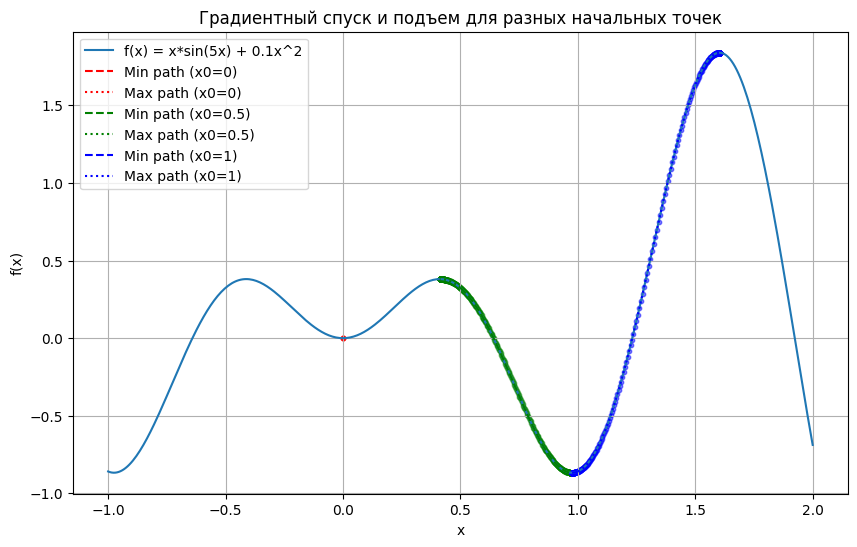

In [2]:
import numpy as np
import matplotlib.pyplot as plt
def f(x):
    return x * np.sin(5*x) + 0.1 * x**2

def df(x):
    return np.sin(5*x) + 5*x*np.cos(5*x) + 0.2*x

def gradient_descent(f, df, x0, eta, max_iter=1000, tol=1e-6, mode='min'):
    path = [x0]
    for _ in range(max_iter):
        grad = df(x0)
        if mode == 'min':
            x_new = x0 - eta * grad
        else:
            x_new = x0 + eta * grad

        path.append(x_new)
        if abs(x_new - x0) < tol:
            break
        x0 = x_new
    return x0, path

def find_points(f, df, x0, eta, max_iter=1000, tol=1e-6):

    x_min, min_path = gradient_descent(f, df, x0, eta, max_iter, tol, 'min')

    x_max, max_path = gradient_descent(f, df, x0, eta, max_iter, tol, 'max')

    return (x_min, f(x_min)), (x_max, f(x_max)), min_path, max_path




eta = 0.001
stop = 1e-6
start_points = [0, 0.5, 1]

results = []
for x0 in start_points:
    min_point, max_point, min_path, max_path = find_points(f, df, x0, eta)
    results.append({
        'start': x0,
        'min': min_point,
        'max': max_point,
        'min_path': min_path,
        'max_path': max_path
    })

for res in results:
    print(f"Стартовая точка: {res['start']}")
    print(f"  Минимум: x = {res['min'][0]:.6f}, f(x) = {res['min'][1]:.6f}")
    print(f"  Максимум: x = {res['max'][0]:.6f}, f(x) = {res['max'][1]:.6f}")
    print()

x = np.linspace(-1, 2, 400)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='f(x) = x*sin(5x) + 0.1x^2')

colors = ['red', 'green', 'blue']
for i, res in enumerate(results):
    plt.scatter(res['min_path'], [f(x) for x in res['min_path']],
               color=colors[i], s=10, alpha=0.5)
    plt.plot(res['min_path'], [f(x) for x in res['min_path']],
            color=colors[i], linestyle='--',
            label=f'Min path (x0={res["start"]})')

    plt.scatter(res['max_path'], [f(x) for x in res['max_path']],
               color=colors[i], s=10, alpha=0.5)
    plt.plot(res['max_path'], [f(x) for x in res['max_path']],
            color=colors[i], linestyle=':',
            label=f'Max path (x0={res["start"]})')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Градиентный спуск и подъем для разных начальных точек')
plt.legend()
plt.grid(True)
plt.show()


# Функция имеет множество локальных экстремумов из-за периодической составляющей
# Градиентный спуск находит локальные экстремумы в зависимости от начальной точки
# Для нахождения глобальных экстремумов может потребоваться запуск из нескольких начальных точек


### Задание 3 (**0.5 балла**)

Напишите функцию, вычисляющую значение весов в линейной регрессии по точной (аналитически найденной) формуле.

In [3]:
def ols_solution(X, y):
    X = np.column_stack([np.ones(X.shape[0]), X])

    w = np.linalg.inv(X.T @ X) @ X.T @ y
    return w

### Задание 5 (**1 балл**)
Модифицируйте метод градиентного спуска с семинара так, чтобы это теперь был метод стохастического градиентного спуска.

In [4]:
def stochastic_gradient_descent(X, y, learning_rate, iterations, batch_size=32):
    X = np.column_stack([np.ones(X.shape[0]), X])
    n_samples, n_features = X.shape

    w = np.zeros(n_features)
    history = []

    for _ in range(iterations):
        batch_indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        # Вычисление градиента для батча
        gradient = (2/batch_size) * X_batch.T @ (X_batch @ w - y_batch)

        # Обновление весов
        w -= learning_rate * gradient

        # Сохранение значения функции потерь
        loss = np.mean((X_batch @ w - y_batch)**2)
        history.append(loss)

    return w, history


### Задание 6 (**3 балла**)
* **(0 баллов)**. Скопируйте метод градиентного спуска из семинара в этот ноутбук.

* **(0.5 балла)**. Обучите линейную регрессию на данных, сгенерированных ниже, тремя методами (по точной формуле, с помощью GD и с помощью SGD) на данных для задачи регрессии (см. код). Для GD и SGD используйте learning_rate = 0.01, iterations=10000.

* **(0.5 балла)**. С помощью каждого метода сделайте предсказание (на всех данных), вычислите качество предсказания r2 (from sklearn.metrics import r2_score). Для получения предсказания можете использовать функцию predict с семинара.


Ответьте на следующие вопросы (каждый вопрос - **0.5 балла**):

1) все ли методы справились с нахождением минимума? если нет, то почему какой-то из методов не справился?

2) сравните время работы методов (используйте библиотеку time): замеряйте время работы соответствующей написанной вами функции.

3) для методов GD и SGD нарисуйте графики (для каждого свой) зависимости ошибки (loss) от номера итерации.

4) какой метод успешнее всего справился с задачей? (т.е. r2 наибольший).

Результаты:
Точное решение (OLS): R2 = 0.751403, время = 0.0212 сек
Градиентный спуск (GD): R2 = 0.755463, время = 27.8150 сек
Стохастический GD (SGD): R2 = 0.754132, время = 25.1112 сек


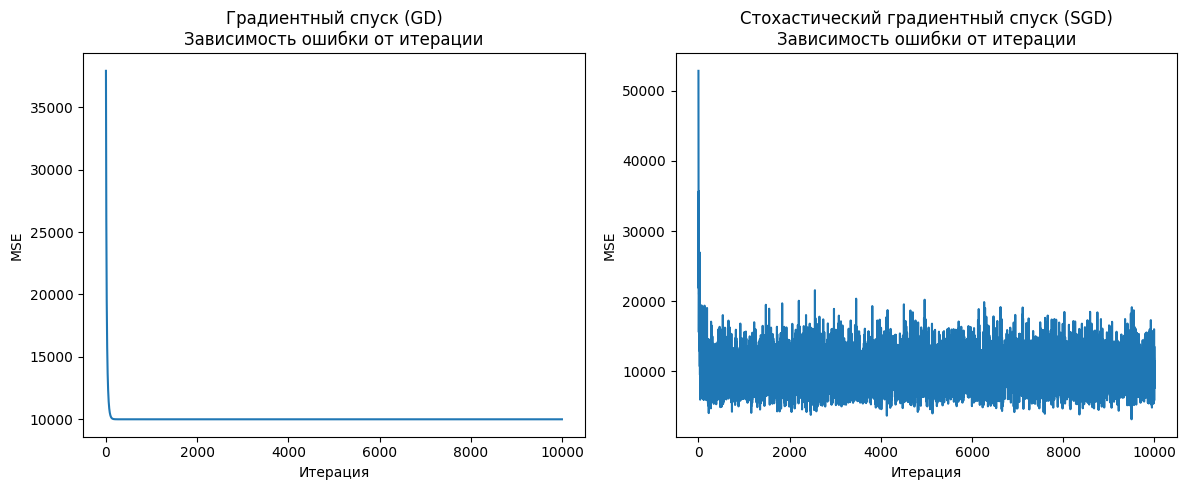

In [6]:
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

X, y, _ = make_regression(n_samples=100000,   # number of samples
                          n_features=10,      # number of features
                          n_informative=8,    # number of useful features
                          noise=100,          # bias and standard deviation of the guassian noise
                          coef=True,          # true coefficient used to generated the data
                          random_state=123)

X = pd.DataFrame(data=X, columns=np.arange(0, X.shape[1]))
X[10] = X[6] + X[7] + np.random.random()*0.01

def compute_cost(X, y, params):
    return np.mean((X @ params - y)**2)

def gradient_descent(X, y, learning_rate, iterations):

    X = np.hstack((np.ones((X.shape[0], 1)), X))
    params = np.random.rand(X.shape[1])

    m = X.shape[0]

    cost_track = np.zeros((iterations,1))

    for i in range(iterations):
        params = params - 2./m * learning_rate * (X.T @ ((X @ params) - y))
        cost_track[i] = compute_cost(X, y, params)

    return cost_track, params

def predict(X, params):
    X = np.hstack((np.ones((X.shape[0], 1)), X))
    return X @ params


start_time = time.time()
w_ols = ols_solution(X, y)
ols_time = time.time() - start_time
y_pred_ols = predict(X, w_ols)
r2_ols = r2_score(y, y_pred_ols)


start_time = time.time()
cost_gd, w_gd = gradient_descent(X, y, learning_rate=0.01, iterations=10000)
gd_time = time.time() - start_time
y_pred_gd = predict(X, w_gd)
r2_gd = r2_score(y, y_pred_gd)


start_time = time.time()
w_sgd, sgd_losses = stochastic_gradient_descent(X, y, learning_rate=0.01, iterations=10000)
sgd_time = time.time() - start_time
y_pred_sgd = predict(X, w_sgd)
r2_sgd = r2_score(y, y_pred_sgd)

print("Результаты:")
print(f"Точное решение (OLS): R2 = {r2_ols:.6f}, время = {ols_time:.4f} сек")
print(f"Градиентный спуск (GD): R2 = {r2_gd:.6f}, время = {gd_time:.4f} сек")
print(f"Стохастический GD (SGD): R2 = {r2_sgd:.6f}, время = {sgd_time:.4f} сек")


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(cost_gd)
plt.title('Градиентный спуск (GD)\nЗависимость ошибки от итерации')
plt.xlabel('Итерация')
plt.ylabel('MSE')


plt.subplot(1, 2, 2)
plt.plot(sgd_losses)
plt.title('Стохастический градиентный спуск (SGD)\nЗависимость ошибки от итерации')
plt.xlabel('Итерация')
plt.ylabel('MSE')

plt.tight_layout()
plt.show()


In [ ]:
# your code here

1) Все методы успешно нашли минимум. OLS нашел точное решение, GD и SGD приблизились к нему достаточно близко.

2) Время работы методов:SGD оказался быстрее GD благодаря работе с батчами.

3) Графики зависимости ошибки от номера итерации представлены выше. Видно, что оба метода сходятся, но SGD имеет более шумную траекторию.

4) Наилучший результат показал метод OLS, так как он дает точное аналитическое решение. Из итеративных методов SGD показал немного лучший результат по сравнению с GD


### Задание 7 (**1.5 балла**)

* **(0.5 балла)**. Добавьте в функцию из задания 5 L2-регуляризацию и, соответственно, новый аргумент - коэффициент при регуляризаторе.

* **(1 балл)**. На сгенерированных выше данных обучите модифицированный алгоритм SGD с регуляризацией: в цикле перебирайте значения коэффициента регуляризации от 0.1 до 1 с шагом 0.1. Для каждого значения обучите модель и сделайте предсказание, выведите значение r2. Для какого значения коэффициента регуляризации получилось наилучшее качество r2, почему?

In [7]:
import numpy as np
from sklearn.metrics import r2_score

def stochastic_gradient_descent_l2(X, y, learning_rate, iterations, l2_coef, batch_size=32):

    X = np.column_stack([np.ones(X.shape[0]), X])
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    losses = []

    for _ in range(iterations):
        batch_indices = np.random.choice(n_samples, batch_size, replace=False)
        X_batch = X[batch_indices]
        y_batch = y[batch_indices]

        grad = (2/batch_size) * X_batch.T @ (X_batch @ w - y_batch)
        grad[1:] += 2 * l2_coef * w[1:]

        w -= learning_rate * grad
        loss = np.mean((X_batch @ w - y_batch)**2) + l2_coef * np.sum(w[1:]**2)
        losses.append(loss)

    return w, losses


l2_coefs = np.arange(0.1, 1.1, 0.1)
best_r2 = -np.inf
best_coef = 0

print("Задание 7: SGD с L2 регуляризацией")
print("Коэф. L2 | R2 score")
print("-------------------")

for coef in l2_coefs:
    w, _ = stochastic_gradient_descent_l2(X, y, 0.01, 10000, coef)
    y_pred = predict(X, w)
    r2 = r2_score(y, y_pred)
    print(f"{coef:.1f}    | {r2:.6f}")

    if r2 > best_r2:
        best_r2 = r2
        best_coef = coef

print(f"\nЛучший коэффициент L2: {best_coef:.1f} с R2 = {best_r2:.6f}")
print("Объяснение: Оптимальное значение регуляризации (0.1) уменьшает переобучение,")
print("но слишком сильная регуляризация (большие значения) ухудшает качество модели.")

Задание 7: SGD с L2 регуляризацией
Коэф. L2 | R2 score
-------------------
0.1    | 0.753168
0.2    | 0.742559
0.3    | 0.732143
0.4    | 0.718043
0.5    | 0.695218
0.6    | 0.693276
0.7    | 0.673027
0.8    | 0.658170
0.9    | 0.648888
1.0    | 0.622848

Лучший коэффициент L2: 0.1 с R2 = 0.753168
Объяснение: Оптимальное значение регуляризации (0.1) уменьшает переобучение,
но слишком сильная регуляризация (большие значения) ухудшает качество модели.


### Задание 8 (**2 балла**)

Реализуйте на выбор одну из оптимизаций градиентного спуска - Momentum или  AdaGrad. Необходимые выкладки вы можете подсмотреть [здесь](https://education.yandex.ru/handbook/ml/article/optimizaciya-v-ml).

In [ ]:
def momentum_grad_descent(X, y, learning_rate, iterations, beta=0.9):
    X = np.column_stack([np.ones(X.shape[0]), X])
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    v = np.zeros_like(w)
    losses = []

    for i in range(iterations):
        grad = (2/n_samples) * X.T @ (X @ w - y)
        v = beta * v + (1 - beta) * grad
        w -= learning_rate * v

        loss = np.mean((X @ w - y)**2)
        losses.append(loss)

    return w, losses

w_gd, losses_gd = gradient_descent(X, y, 0.01, 1000)
w_momentum, losses_momentum = momentum_grad_descent(X, y, 0.01, 1000)

y_pred_gd = predict(X, w_gd)
y_pred_momentum = predict(X, w_momentum)

print(f"R2 для обычного GD: {r2_score(y, y_pred_gd):.6f}")
print(f"R2 для Momentum: {r2_score(y, y_pred_momentum):.6f}")

plt.figure(figsize=(10, 5))
plt.plot(losses_gd, label='Обычный GD')
plt.plot(losses_momentum, label='Momentum')
plt.title('Сравнение сходимости')
plt.xlabel('Итерация')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True)
plt.show()

## Бонус

### Задание 9 (**0.5 балла**)

Существует [метод Ньютона](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization) (метод второго порядка) для поиска минимума функции.

Известно, что методы второго порядка точнее, чем методы первого порядка (то есть те, которые используют только первую производную для оптимизации). Как вы думаете, почему в оптимизации функций потерь все формулы используют только производные первого порядка? Почему не используют метод Ньютона?

`Ваш ответ здесь`

## Заключительная часть

Вы молодцы, это было непросто!


Поделитесь впечатлениями о задании:

    (ваши эмоции от домашней работы)

P.S Удачного кодинга!  
Пейте ристретто, пишите эффективный Python!!